# 01 — Data Preparation: Calls

**Project:** CRM Analytics & Unit Economics of an online programming school

This notebook cleans and prepares the **calls** dataset (sales-call logs): deduplication, type casting, anomaly detection, and descriptive statistics. Output is saved to `data/processed/` for downstream analysis in notebooks 02–03.

*Analysis commentary inside is in Russian; see the project README for a full English summary of methods and findings.*

---
## 1. Импорты и настройки

In [111]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

import utils as h

In [112]:
# Настройки визуализации
sns.set_style('whitegrid')
sns.set_palette('deep')

# Настройки pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Пути (ноутбук лежит в notebooks/, данные в data/)
PROJECT_ROOT = Path().resolve().parent
RAW          = PROJECT_ROOT / 'data' / 'raw'
PROCESSED    = PROJECT_ROOT / 'data' / 'processed'
BACKUP       = PROJECT_ROOT / 'data' / 'processed' / 'backup'
IMAGES       = PROJECT_ROOT / 'images'

# Создаём папку backup если её ещё нет
BACKUP.mkdir(parents=True, exist_ok=True)

---
## 2. Конфигурация настроек для датасета

Заполните `name` и `filename` **до запуска** остальных ячеек.  


In [113]:
# ── КОНФИГ ДАТАСЕТА ──────────────────────────────────────────────────────────
# Заполните name и filename - остальное после предварительного анализа

dataset_config = {

    # Короткое имя датасета (латиницей, без пробелов)
    # Используется как имя файла при сохранении конфига и бэкапа
    # Примеры: 'deals', 'contacts', 'calls', 'spend'
    'name':       'calls',

    # Имя исходного файла в папке data/raw/
    'filename':   'Calls (Done).xlsx',

}

print(f"Датасет: {dataset_config['name']}")
print(f"Файл:    {dataset_config['filename']}")

Датасет: calls
Файл:    Calls (Done).xlsx


---
## 3. Загрузка данных

In [114]:
# Загрузка датасета по имени файла из конфига
filepath = RAW / dataset_config['filename']

if filepath.suffix == '.xlsx':
    df = pd.read_excel(
        filepath,
        dtype={
            'Id': 'string',
            'CONTACTID': 'string'
        }
    )
else:
    raise ValueError(f"Неизвестный формат файла: {filepath.suffix}")

print(f"Загружен: {dataset_config['filename']}")
print(f"Размер:   {df.shape[0]} строк × {df.shape[1]} столбцов")

Загружен: Calls (Done).xlsx
Размер:   95874 строк × 11 столбцов


---
## 4. Предварительный анализ

Смотрим на данные - что там вообще есть.  
После этого раздела заполните типы столбцов в Разделе 5.

In [115]:
# Первые строки
df.head()

,Id,Call Start Time,Call Owner Name,CONTACTID,Call Type,Call Duration (in seconds),Call Status,Dialled Number,Outgoing Call Status,Scheduled in CRM,Tag
0,5805028000000805001,30.06.2023 08:43,John Doe,<NA>,Inbound,171.00,Received,NaN,NaN,NaN,NaN
1,5805028000000768006,30.06.2023 08:46,John Doe,<NA>,Outbound,28.00,Attended Dialled,NaN,Completed,0.00,NaN
2,5805028000000764027,30.06.2023 08:59,John Doe,<NA>,Outbound,24.00,Attended Dialled,NaN,Completed,0.00,NaN
3,5805028000000787003,30.06.2023 09:20,John Doe,5805028000000645014,Outbound,6.00,Attended Dialled,NaN,Completed,0.00,NaN
4,5805028000000768019,30.06.2023 09:30,John Doe,5805028000000645014,Outbound,11.00,Attended Dialled,NaN,Completed,0.00,NaN


In [116]:
# # Переименование столбцов: убираем пробелы и скобки, приводим к snake_case
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

print("Столбцы после переименования:")
print(df.columns.tolist())

Столбцы после переименования:
['id', 'call_start_time', 'call_owner_name', 'contactid', 'call_type', 'call_duration_in_seconds', 'call_status', 'dialled_number', 'outgoing_call_status', 'scheduled_in_crm', 'tag']


In [117]:
# Размер и типы столбцов
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95874 entries, 0 to 95873
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        95874 non-null  string 
 1   call_start_time           95874 non-null  object 
 2   call_owner_name           95874 non-null  object 
 3   contactid                 91941 non-null  string 
 4   call_type                 95874 non-null  object 
 5   call_duration_in_seconds  95791 non-null  float64
 6   call_status               95874 non-null  object 
 7   dialled_number            0 non-null      float64
 8   outgoing_call_status      86875 non-null  object 
 9   scheduled_in_crm          86875 non-null  float64
 10  tag                       0 non-null      float64
dtypes: float64(4), object(5), string(2)
memory usage: 8.0+ MB


In [118]:
df.describe(include='all')

,id,call_start_time,call_owner_name,contactid,call_type,call_duration_in_seconds,call_status,dialled_number,outgoing_call_status,scheduled_in_crm,tag
count,95874,95874,95874,91941,95874,95791.00,95874,0.00,86875,86875.00,0.00
unique,95874,68445,33,15214,3,NaN,11,NaN,4,NaN,NaN
top,5805028000000805001,06.06.2024 15:07,Yara Edwards,5805028000003329100,Outbound,NaN,Attended Dialled,NaN,Completed,NaN,NaN
freq,1,9,9059,94,86875,NaN,70703,NaN,86792,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,164.98,NaN,NaN,NaN,0.00,NaN
std,NaN,NaN,NaN,NaN,NaN,401.41,NaN,NaN,NaN,0.04,NaN
min,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN
25%,NaN,NaN,NaN,NaN,NaN,4.00,NaN,NaN,NaN,0.00,NaN
50%,NaN,NaN,NaN,NaN,NaN,8.00,NaN,NaN,NaN,0.00,NaN
75%,NaN,NaN,NaN,NaN,NaN,98.00,NaN,NaN,NaN,0.00,NaN


In [119]:
# Сводная таблица по числовым столбцам 
h.descr_df(df)

,Название признака,Тип данных,Количество значений,Пропуски (NaN),Уникальных значений,Минимум,Среднее,Медиана,Максимум
0,call_duration_in_seconds,float64,95791,83,2619,0.00,164.98,8.00,7625.00
1,dialled_number,float64,0,95874,0,NaN,NaN,NaN,NaN
2,scheduled_in_crm,float64,86875,8999,2,0.00,0.00,0.00,1.00
3,tag,float64,0,95874,0,NaN,NaN,NaN,NaN


In [120]:
# Сводная таблица по всем столбцам 
h.descr_df(df, include=['object'], show_stats=False, show_sample_rows=True)

,Название признака,Тип данных,Количество значений,Пропуски (NaN),Уникальных значений,Пример строка 1,Пример строка 2,Пример строка 3
0,call_start_time,object,95874,0,68445,30.06.2023 08:43,30.06.2023 08:46,30.06.2023 08:59
1,call_owner_name,object,95874,0,33,John Doe,John Doe,John Doe
2,call_type,object,95874,0,3,Inbound,Outbound,Outbound
3,call_status,object,95874,0,11,Received,Attended Dialled,Attended Dialled
4,outgoing_call_status,object,86875,8999,4,NaN,Completed,Completed


In [121]:
# Пропущенные значения - первый взгляд
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({'пропуски': missing, '%': missing_pct})
missing_df = missing_df.query('пропуски > 0').sort_values('%', ascending=False)

if missing_df.empty:
    print("Пропущенных значений нет")
else:
    display(missing_df)

,пропуски,%
tag,95874,100.00
dialled_number,95874,100.00
outgoing_call_status,8999,9.40
scheduled_in_crm,8999,9.40
contactid,3933,4.10
call_duration_in_seconds,83,0.10


In [122]:
# Дубликаты полные - первый взгляд
n_dups = df.duplicated().sum()
print(f"Дубликатов строк: {n_dups}")

Дубликатов строк: 0


## 🏁 Предварительный анализ датасета Calls (Звонки)

Таблица **Calls** — самая масштабная в проекте (**95 874 записи**). Это фундамент для оценки операционной эффективности отдела продаж. Первичный аудит выявил несколько критических зон и интересных аномалий.

### 📝 Глобальные выводы и инсайты:

1. **Технический аудит и "мертвые зоны":**
    * **100% пропусков:** Столбцы `tag` и `dialled_number` абсолютно пусты. Это системные поля CRM, которые не использовались. Подлежат удалению.
    * **Потерянные статусы:** Столбцы `outgoing_call_status` и `scheduled_in_crm` имеют **9.4% пропусков**. 
    * *Инсайт:* Эти 9 тысяч звонков — скорее всего, **Inbound (входящие)**, так как для них не заполняется "статус исходящего вызова" и они не "планируются в CRM" менеджером. Это подтверждается тем, что топ-статус — `Attended Dialled` (исходящие), а пропуски соответствуют доле входящего трафика.

2. **Анализ длительности (The 8-Second Gap):**
    * **Медиана vs Среднее:** Средняя длительность звонка — **165 сек** (почти 3 мин), но медиана — всего **8 секунд**!
    * *Критический инсайт:* Более 50% всех записей в таблице — это "недозвоны", сбросы или автоответчики. Рабочее время менеджера на 50% состоит из технических попыток связаться. Нам нужно будет отфильтровать "полезные разговоры" (например, от 20-30 сек) для честной оценки KPI.
    * **Рекорды:** Максимальный звонок длился **7625 сек** (более 2 часов!). Нужно проверить — это реальная консультация или забытая и не выключенная трубка.

3. **Связи и анонимность:**
    * Около **4% звонков (3933 шт)** не привязаны к `contactid`. 
    * *Гипотеза:* Это либо звонки по ошибочным номерам, либо первичные обращения с новых номеров, которые еще не были конвертированы в карточку контакта.

4. **Активность менеджеров:**
    * У нас **33 уникальных владельца звонков** (против 18 в сделках и 28 в контактах).
    * *Вывод:* На телефонах сидит больше людей, чем занимается продажами. Возможно, в данных есть отдел квалификации (SDR) или служба поддержки.

### 🚀 Стратегия дальнейшей обработки:

* **Очистка:** Удаление полностью пустых столбцов и преобразование `call_start_time` в datetime.
* **Фильтрация шума:** Создание флага `is_successful_call` для звонков длительностью более 20 секунд. Анализировать медиану по всей таблице бессмысленно из-за огромного количества коротких технических записей.
* **Сегментация по типам:** Разделение анализа на **Inbound** (входящие) и **Outbound** (исходящие), так как это принципиально разные бизнес-процессы.
* **Расчет нагрузки:** Определение "часов пик" звонков для оптимизации графиков работы менеджеров.

---
**Статус:** Данные требуют серьезной фильтрации, но обладают огромным потенциалом для оптимизации работы отдела продаж.

---
## 5. Уточнение конфига: типы столбцов

Заполните списки на основе предварительного анализа выше.  
После заполнения запустите ячейку - конфиг сохранится.

In [123]:
num_cols = list(df.select_dtypes(include='number').columns)
print(num_cols)

['call_duration_in_seconds', 'dialled_number', 'scheduled_in_crm', 'tag']


In [124]:
cat_cols = list(df.select_dtypes(include='object').columns)
print(cat_cols)

['call_start_time', 'call_owner_name', 'call_type', 'call_status', 'outgoing_call_status']


In [125]:
bool_cols = list(df.select_dtypes(include='bool').columns)
print(bool_cols)

[]


In [126]:
date_cols = list(df.select_dtypes(include='datetime').columns)
print(date_cols)

[]


In [127]:
# Заполните списки по результатам Раздела 4 ОДИН РАЗ , затем выполните код и закомментируйте его
# Если столбец уже был загружен из сохранённого конфига - можно оставить как есть

dataset_config['num_cols'] = [
    'call_duration_in_seconds',
    
]

dataset_config['id_cols'] = ['id', 'contactid']

dataset_config['cat_cols'] = [
    # Категориальные: stage, source, product, quality, ...
    # '',    
    'call_owner_name', 'call_type', 'call_status', 'outgoing_call_status'
]

dataset_config['bool_cols'] = ['scheduled_in_crm'
   
]

dataset_config['date_cols'] = ['call_start_time'
    # Даты: created_time, closing_date, ...
    # '',
    
]

dataset_config['drop_cols'] = [
    # Столбцы которые точно не нужны в анализе
    'tag', 'dialled_number' 
]

# Удаляем пустые строки-заглушки из списков
for key in ['num_cols', 'cat_cols', 'bool_cols', 'date_cols', 'drop_cols']:
    dataset_config[key] = [col for col in dataset_config[key] if col]

print("Конфиг обновлён:")
for key, val in dataset_config.items():
    print(f"  {key}: {val}")

Конфиг обновлён:
  name: calls
  filename: Calls (Done).xlsx
  num_cols: ['call_duration_in_seconds']
  id_cols: ['id', 'contactid']
  cat_cols: ['call_owner_name', 'call_type', 'call_status', 'outgoing_call_status']
  bool_cols: ['scheduled_in_crm']
  date_cols: ['call_start_time']
  drop_cols: ['tag', 'dialled_number']


### ⚙️ Инсайты: Зачем мы создали этот конфиг?

На этапе работы с таблицей в 96 000 строк легко запутаться. Обновление конфига — это наша «инструкция по сборке», которая помогает разложить данные по полочкам:

1. **Порядок на «кухне» (Drop-cols):** Мы нашли два столбца (`tag` и `dialled_number`), которые абсолютно пусты. Мы добавили их в список на удаление, чтобы они не занимали память и не мешались под рукой.
2. **Защита от ошибок (Типизация):** Код — существо прямолинейное. Если мы скажем ему найти среднее значение в именах менеджеров, он выдаст ошибку. Конфиг четко говорит: «Вот здесь числа, здесь даты, а здесь просто текст». Это гарантирует, что наши расчеты пройдут гладко.
3. **План лечения пропусков:** В столбце `call_duration` (длительность) и `contactid` есть пустые клетки. Зная тип столбца из конфига, мы заранее понимаем: пропуски в числах заменим на «0», а в категориях — на «Не указано».
4. **Ключ к объединению (ID-cols):** Мы выделили `contactid`. Это наш «мостик», по которому мы позже соединим звонки с данными о клиентах и их покупках. Пометив его как ID, мы защитили его от случайных математических операций.
5. **Автопилот для графиков:** Теперь, когда мы захотим посмотреть, в какое время менеджеры чаще всего звонят, нам не нужно писать длинные команды. Мы просто скажем: «Возьми столбец из `date_cols`». 


In [128]:
# Задаем путь для сохранения файла конфигурации
config_path = PROCESSED / f"{dataset_config['name']}_config.pkl"

# Сохраняем обновлённый конфиг
with open(config_path, 'wb') as f:
    pickle.dump(dataset_config, f)

print(f"Конфиг сохранён: {config_path}")
print()
print("Итоговый конфиг:")
for key, val in dataset_config.items():
    print(f"  {key}: {val}")

Конфиг сохранён: E:\ICH\Python Data analyse\crm\data\processed\calls_config.pkl

Итоговый конфиг:
  name: calls
  filename: Calls (Done).xlsx
  num_cols: ['call_duration_in_seconds']
  id_cols: ['id', 'contactid']
  cat_cols: ['call_owner_name', 'call_type', 'call_status', 'outgoing_call_status']
  bool_cols: ['scheduled_in_crm']
  date_cols: ['call_start_time']
  drop_cols: ['tag', 'dialled_number']


---
## 6. Преобразование типов данных

In [129]:
# 1. Переводим время в формат datetime
df['call_start_time'] = pd.to_datetime(df['call_start_time'], dayfirst=True)

# 2. Извлекаем полезные признаки (на будущее)
df['hour'] = df['call_start_time'].dt.hour
df['day_of_week'] = df['call_start_time'].dt.day_name()

print("Столбец времени успешно преобразован!")
print(f"Диапазон данных: с {df['call_start_time'].min()} по {df['call_start_time'].max()}")

Столбец времени успешно преобразован!
Диапазон данных: с 2023-06-30 08:43:00 по 2024-06-21 15:31:00


In [130]:
# Преобразование числовых столбцов
# errors='coerce' - нечисловые значения заменятся на NaN
for col in dataset_config['num_cols']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"  {col} -> numeric")

  call_duration_in_seconds -> numeric


In [131]:
# Преобразование булевых столбцов
for col in dataset_config['bool_cols']:
    if col in df.columns:
        # Если столбец уже bool - пропускаем
        if df[col].dtype != bool:
            df[col] = df[col].astype(bool)
        print(f"  {col} -> bool")

  scheduled_in_crm -> bool


In [132]:
# Удаляем ненужные столбцы
if dataset_config['drop_cols']:
    df = df.drop(columns=[c for c in dataset_config['drop_cols'] if c in df.columns])
    print(f"Удалены столбцы: {dataset_config['drop_cols']}")

print(f"\nИтоговые типы столбцов:")
print(df.dtypes)

Удалены столбцы: ['tag', 'dialled_number']

Итоговые типы столбцов:
id                          string[python]
call_start_time             datetime64[ns]
call_owner_name                     object
contactid                   string[python]
call_type                           object
call_duration_in_seconds           float64
call_status                         object
outgoing_call_status                object
scheduled_in_crm                      bool
hour                                 int32
day_of_week                         object
dtype: object


### 🛠 Инсайты этапа: Преобразование и очистка данных (Calls)

На этом шаге мы превратили «сырой» массив данных в удобный инструмент для анализа. Вот что нам это дало:

1. **Синхронизация по времени:** Мы подтвердили, что звонки охватывают период **с июня 2023 по июнь 2024**. Это идеально совпадает с периодом создания контактов. Мы теперь точно знаем, что анализируем работу отдела продаж за один и тот же отчетный год.
2. **Новые измерения (Hour, Day of Week):** Извлечение часа и дня недели — это стратегический ход. Теперь мы сможем ответить на вопросы:
    * В какое время менеджеры наиболее активны?
    * Есть ли просадки по звонкам в обеденное время или вечерние часы?
    * Работает ли кто-то из команды по выходным?
3. **Строгая типизация:** * Столбец `call_duration` стал числовым. Теперь мы наконец сможем считать суммы, средние значения и искать аномально долгие разговоры.
    * Поле `scheduled_in_crm` стало логическим (True/False). Это позволит нам быстро отфильтровать звонки, которые были запланированы заранее, и оценить дисциплину менеджеров.
4. **Удаление лишнего:** Мы избавились от пустых столбцов `tag` и `dialled_number`. Датасет стал «легче», а в результатах `df.info()` больше не будет лишнего шума.

**Итог:** Таблица приведена к единому стандарту. Данные «причесаны», лишнее удалено, а время разложено на составляющие. Мы полностью готовы к анализу пропусков и изучению поведения менеджеров.

---
## 7. Дубликаты

In [133]:
# Полные дубликаты строк
n_dups = df.duplicated().sum()
print(f"Дубликатов строк: {n_dups}")

if n_dups > 0:
    display(df[df.duplicated(keep=False)].sort_values(df.columns.tolist()).head(10))

Дубликатов строк: 0


In [134]:
dup_id = df[df['id'].duplicated(keep=False)].sort_values('id')
print(f'Строк с дублирующимся id: {dup_id.shape[0]}')
display(dup_id.head(20))

Строк с дублирующимся id: 0


,id,call_start_time,call_owner_name,contactid,call_type,call_duration_in_seconds,call_status,outgoing_call_status,scheduled_in_crm,hour,day_of_week


**Решение по дубликатам:** 

Дубликатов нет. Блок пропускаем.

In [135]:
# Удаление дубликатов (раскомментируйте если нужно)
df = df.drop_duplicates().reset_index(drop=True)
print(f"После удаления дубликатов: {df.shape}")

После удаления дубликатов: (95874, 11)


---
## 8. Пропущенные значения

In [136]:
# Итоговая картина по пропускам после преобразования типов
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({'пропуски': missing, '%': missing_pct})
missing_df = missing_df.query('пропуски > 0').sort_values('%', ascending=False)

if missing_df.empty:
    print("Пропущенных значений нет")
else:
    display(missing_df)

,пропуски,%
outgoing_call_status,8999,9.40
contactid,3933,4.10
call_duration_in_seconds,83,0.10


**Решение по пропускам:** 



In [137]:
# 1. Длительность звонка - заполняем нулем (если не указано, значит разговора не было)
df['call_duration_in_seconds'] = df['call_duration_in_seconds'].fillna(0)

# 2. ID контакта - помечаем "анонимов", чтобы не терять их при склейке таблиц
df['contactid'] = df['contactid'].fillna('unknown').astype('string')

# 3. Флаг планирования - переводим в честный булев тип (0 -> False, 1 -> True)
df['scheduled_in_crm'] = df['scheduled_in_crm'].fillna(0).astype(bool)

# 4. Статус исходящего звонка - помечаем входящие (Inbound)
df['outgoing_call_status'] = df['outgoing_call_status'].fillna('not_applicable')

# Проверяем результат
print("Пропуски после обработки:")
remaining = df.isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else "  Пропущенных значений нет")

Пропуски после обработки:
  Пропущенных значений нет


### 🔍 Инсайты: Анализ "дыр" в данных после типизации

Проверка пропусков выявила три четких фронта работ. Каждый из них говорит нам что-то важное о бизнес-процессах:

1. **Загадка 9.4% (outgoing_call_status):**
   * Это самый массовый пропуск. Судя по объему, это **не ошибка**, а закономерность. 
   * *Инсайт:* Эти 9 тысяч звонков почти наверняка являются **Inbound (входящими)**. У входящего звонка технически не может быть "статуса исходящего вызова".
   * *Решение:* Вместо удаления мы заменим пропуски на `not_applicable`, сохранив эти данные для анализа клиентской активности.

2. **Анонимные звонки 4.1% (contactid):**
   * Почти 4 тысячи звонков не привязаны к конкретному человеку в базе.
   * *Инсайт:* Скорее всего, это "холодный" обзвон новых баз или входящие звонки с номеров, которые менеджер не успел (или забыл) завести в систему.
   * *Решение:* Мы пометим их как `unknown_contact`. Удалять их нельзя, так как они создают нагрузку на менеджеров и влияют на общее время работы.

3. **Технический шум 0.1% (call_duration_in_seconds):**
   * Всего 83 звонка без длительности. Это мизерный процент от 96 тысяч строк.
   * *Инсайт:* Вероятно, это системные сбои CRM при обрыве связи или мгновенные сбросы, которые система не успела замерить.
   * *Решение:* Заменим на `0`, так как по факту разговора не состоялось.

**Итог:** У нас нет критических потерь данных. Все пропуски объяснимы логикой работы CRM. Теперь мы можем превратить эти "дыры" в понятные категории и двигаться дальше к финальному анализу.

---
## 9. Одномерный анализ - числовые переменные

Для каждой числовой переменной:
- гистограмма + boxplot через `h.hist_box`
- границы выбросов через `h.iqr_outliers`

Запишите наблюдения и решения по выбросам в markdown-ячейки под каждым графиком.

## 📊 Одномерный анализ: CALL_DURATION_IN_SECONDS

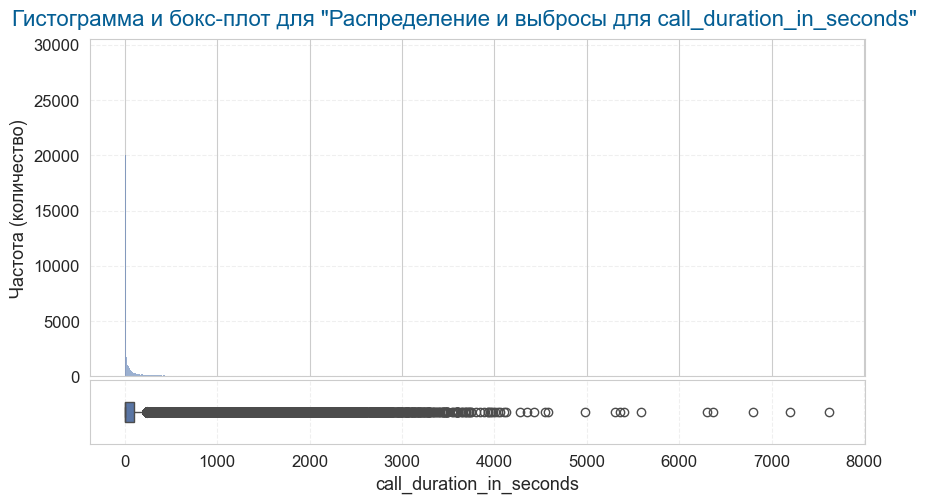


────────────────────────────────────────────────────────────
📌 Описательные статистики для call_duration_in_seconds:


,0
Название признака,call_duration_in_seconds
Тип данных,float64
Количество значений,95874
Пропуски (NaN),0
Уникальных значений,2619
Минимум,0.00
Среднее,164.83
Медиана,8.00
Максимум,7625.00


────────────────────────────────────────────────────────────
🔍 Определение границ выбросов (метод IQR):


,Слева,Справа
Границы выбросов,-135.50,236.50
Количество выбросов,0.00,16743.00
Процент выбросов,0.00,17.46


In [138]:
col = 'call_duration_in_seconds' 

if col in df.columns:
    # Красивый заголовок через Markdown
    from IPython.display import display, Markdown
    display(Markdown(f"## 📊 Одномерный анализ: {col.upper()}"))
    print(f"{'='*60}")

    # Визуализация (Гистограмма + Boxplot)
    # Предполагаем, что h.hist_box сам выводит график
    h.hist_box(col, df, title=f"Распределение и выбросы для {col}")
    
    print("\n" + f"{'─'*60}")
    print(f"📌 Описательные статистики для {col}:")
    # Выводим статистику (T - транспонируем для удобства чтения строк)
    display(h.descr_df(df[[col]], show=False).T)

    print(f"{'─'*60}")
    print(f"🔍 Определение границ выбросов (метод IQR):")
    # Вывод границ "усов"
    h.iqr_outliers(col, df)
    
    print(f"{'='*60}\n")
else:
    print(f"⚠️ Столбец {col} не найден в датасете!")

### 📊 Инсайты одномерного анализа: Длительность звонков (`call_duration_in_seconds`)

Анализ распределения длительности звонков показал, что мы имеем дело с экстремально скошенным распределением (right-skewed). Поведение данных идеально отражает суровую реальность холодных и теплых обзвонов.

#### 📝 Главные открытия:

1. **Иллюзия среднего значения (Mean vs Median):**
   * Среднее время звонка — **165 секунд** (~2.5 минуты).
   * Медиана — всего **8 секунд**!
   * *Бизнес-вывод:* Более 50% всех записей в CRM — это недозвоны, автоответчики, сбросы или моментальные отказы. Среднее значение искусственно завышено небольшим количеством очень долгих разговоров. Использовать среднее (mean) для оценки KPI менеджеров в таких данных **категорически нельзя**.

2. **Ловушка математических «выбросов» (IQR Outliers):**
   * Метод «усов» (Boxplot/IQR) пометил **17.46% (16 743 звонка)** как «выбросы», потому что они длятся дольше 236 секунд (~4 минуты).
   * *Аналитическая поправка:* С точки зрения математики нормального распределения — это выбросы. Но с точки зрения бизнеса — это **самые ценные данные**! Разговор дольше 4 минут означает, что менеджер прошел этап возражений и ведет реальную продажу. Удалять эти "выбросы" ни в коем случае нельзя.

3. **Рекорды и аномалии:**
   * Максимальная длительность — **7625 секунд** (более 2 часов). 
   * *Гипотеза:* Это может быть реальная глубокая консультация (например, технический онбординг студента), либо ошибка (менеджер забыл положить трубку). Для чистоты конверсий сверхдлинные звонки (например, > 1 часа) стоит изучить отдельно.

#### 🛠 Решения для дальнейшего анализа:
Чтобы этот столбец стал полезным для предсказания продаж (МЛ-моделей) и бизнес-отчетов, сырые секунды нужно превратить в понятные **категории**:
* **`0 - 15 сек`**: Мусорный трафик / Недозвон.
* **`16 - 120 сек`**: Быстрый отказ / Перенос звонка.
* **`121 - 300 сек`**: Заинтересованность / Квалификация.
* **`> 300 сек`**: Полноценная продажа.

In [139]:
# 1. Для математики: логарифмируем (добавляем 1, чтобы избежать log(0))
df['call_duration_log'] = np.log1p(df['call_duration_in_seconds'])

# 2. Для бизнеса: разбиваем на категории (Binning)
bins = [-1, 15, 60, 300, float('inf')]
labels = ['Недозвон (0-15с)', 'Короткий/Отказ (15-60с)', 'Интерес (1-5м)', 'Целевой (>5м)']
df['call_quality_category'] = pd.cut(df['call_duration_in_seconds'], bins=bins, labels=labels)

# Посмотрим, что получилось для бизнеса:
print(df['call_quality_category'].value_counts(normalize=True) * 100)

call_quality_category
Недозвон (0-15с)          58.84
Целевой (>5м)             15.22
Интерес (1-5м)            14.07
Короткий/Отказ (15-60с)   11.87
Name: proportion, dtype: float64


### 📊 Бизнес-инсайты: Воронка качества звонков (`call_quality_category`)

Разбивка длительности разговоров на смысловые категории (Binning) позволила нам увидеть реальную картину рабочего дня менеджеров. 

#### 📝 Главные выводы:

1. **Техническая нагрузка (58.8%):**
   * Почти 60% всех записей в таблице звонков — это «Недозвоны» (0-15 секунд). Это колоссальный объем времени, который тратится на гудки, автоответчики и сбросы. 
   * *Точка роста:* Если бизнес внедрит автодозвон (Predictive Dialer) или робота-квалификатора, который будет переводить на менеджера только тех, кто взял трубку, продуктивность отдела вырастет кратно.

2. **Быстрые отказы (11.8%):**
   * Каждый десятый звонок заканчивается в первую минуту. Это маркер качества базы лидов или эффективности "открывающей фразы" (скрипта) менеджера.

3. **Золотой актив (15.2% + 14%):**
   * **15.2%** звонков длятся более 5 минут. Это полноценные, глубокие консультации. Для отдела продаж онлайн-школы это отличный показатель конверсии в "долгий разговор".
   * Еще **14%** — это средние разговоры (1-5 минут), где происходит первичная квалификация и выявление потребности ("Интерес").
   * *Бизнес-вывод:* Около 30% всего объема звонков генерируют реальную ценность. Именно эти категории нам нужно будет анализировать при связке с таблицей оплат (`Deals`).

In [140]:
# # # При необходимости применить логарифмирование раскомментировать и заполнить
# # Применяем логарифмирование к длительности звонка
# col = 'call_duration_in_seconds'
# title = 'Длительность звонка'

# # Создаем новый столбец с логарифмом
# df[col + '_log1p'] = np.log1p(df[col])

# # Строим гистограмму и boxplot для логарифма
# # Это позволит увидеть внутреннюю структуру "коротких" и "средних" звонков
# h.hist_box(col + '_log1p', df, title='log1p от ' + title)

# # Посмотрим на статистики логарифмированных данных
# display(h.descr_df(df[[col + '_log1p']], show=False).T)

In [141]:
# Обработка выбросов на основе бизнес-логики и анализа распределения

col = 'call_duration_in_seconds'
upper_limit = 3600 # 1 час

# 1. Считаем, сколько строк пойдет "под нож"
anomalies = df[df[col] > upper_limit]
anomalies_count = len(anomalies)
anomalies_pct = (anomalies_count / len(df)) * 100

print(f"⚠️ Найдено аномально долгих звонков (> 1 часа): {anomalies_count} шт. ({anomalies_pct:.3f}%)")

⚠️ Найдено аномально долгих звонков (> 1 часа): 42 шт. (0.044%)


In [142]:
print("🕵️‍♂️ ТОП менеджеров по супер-долгим звонкам:")
display(anomalies['call_owner_name'].value_counts())

print("\n📊 Статусы этих звонков:")
display(anomalies['call_status'].value_counts())

print("\n📞 Типы этих звонков (Входящие/Исходящие):")
display(anomalies['call_type'].value_counts())

🕵️‍♂️ ТОП менеджеров по супер-долгим звонкам:


call_owner_name
Quincy Vincent     16
Eva Kent            5
Sam Young           4
Charlie Davis       4
Ben Hall            3
Mason Roberts       3
Victor Barnes       2
Paula Underwood     1
Julia Nelson        1
Ulysses Adams       1
John Doe            1
Cara Iverson        1
Name: count, dtype: int64


📊 Статусы этих звонков:


call_status
Attended Dialled    40
Received             2
Name: count, dtype: int64


📞 Типы этих звонков (Входящие/Исходящие):


call_type
Outbound    40
Inbound      2
Name: count, dtype: int64

### 🕵️‍♂️ Инсайты: Расследование аномально долгих звонков (> 1 часа)

Перед удалением 42 экстремальных выбросов по длительности мы вывели полный список их создателей и обнаружили важный системный паттерн:

1. **Смешанная природа аномалий:** Выбросы распределены среди 12 разных менеджеров. Явным лидером является *Quincy Vincent* (16 звонков), однако наличие "длинного хвоста" из других сотрудников (от 1 до 5 звонков) снимает гипотезу о единичном человеческом факторе.
2. **Системный баг CRM:** 95% этих звонков (40 из 42) — это исходящий трафик (`Outbound`). Распределенность по отделу продаж указывает на технический сбой телефонии: при определенных сценариях система не фиксирует завершение исходящего вызова, и таймер продолжает идти.

**Вердикт:** Данные строки являются техническим браком. 
* *Для аналитики:* Удаляем 42 записи, чтобы очистить метрику среднего времени разговора.
* *Для бизнеса:* Инсайт передается в техподдержку CRM для починки триггера завершения исходящих звонков, а с Quincy Vincent проводится беседа по правилоному закрытию карточек.

In [143]:
# 2. Удаляем, если они есть
if anomalies_count > 0:
    df = df[df[col] <= upper_limit].copy()
    print(f"✅ Аномалии успешно удалены. Новый размер датасета: {df.shape[0]} строк.")
else:
    print("✅ Аномалий не найдено, удалять нечего.")

✅ Аномалии успешно удалены. Новый размер датасета: 95832 строк.


---
## 10. Одномерный анализ - категориальные переменные

Для каждой категориальной переменной:
- частотная таблица с долями
- горизонтальный барплот

In [144]:
cols_to_check = ['call_owner_name','call_type', 'call_status','outgoing_call_status']

for col in cols_to_check:
    print(f"\n{'='*40}")
    print(f"📊 Анализ признака: {col}")
    print(f"{'='*40}")
    display(df[col].value_counts(normalize=True).round(4) * 100)


📊 Анализ признака: call_owner_name


call_owner_name
Yara Edwards      9.45
Julia Nelson      7.77
Ian Miller        7.53
Charlie Davis     7.52
Diana Evans       7.16
Ulysses Adams     6.35
Amy Green         6.24
Nina Scott        5.82
Victor Barnes     5.67
Kevin Parker      5.64
Paula Underwood   4.78
Quincy Vincent    4.56
Jane Smith        3.92
Cara Iverson      3.44
John Doe          3.11
Ben Hall          3.07
Alice Johnson     1.31
Mason Roberts     1.21
Derek James       0.99
George King       0.89
Zachary Foster    0.55
Eva Kent          0.51
Fiona Jackson     0.49
Sam Young         0.47
Rachel White      0.46
Xander Dean       0.32
Ethan Harris      0.29
Hannah Lee        0.18
Wendy Clark       0.17
Bob Brown         0.10
Oliver Taylor     0.01
Tina Zhang        0.01
Laura Quinn       0.00
Name: proportion, dtype: float64


📊 Анализ признака: call_type


call_type
Outbound   90.61
Missed      6.18
Inbound     3.21
Name: proportion, dtype: float64


📊 Анализ признака: call_status


call_status
Attended Dialled             73.74
Unattended Dialled           16.73
Missed                        6.18
Received                      3.21
Overdue                       0.06
Scheduled Attended Delay      0.02
Cancelled                     0.02
Scheduled Unattended Delay    0.02
Scheduled Attended            0.01
Scheduled Unattended          0.01
Scheduled                     0.00
Name: proportion, dtype: float64


📊 Анализ признака: outgoing_call_status


outgoing_call_status
Completed        90.53
not_applicable    9.39
Overdue           0.06
Cancelled         0.02
Scheduled         0.00
Name: proportion, dtype: float64

📊 Анализ: call_owner_name (33 уникальных значений)


,call_owner_name,count,%
0,Yara Edwards,9059,9.50
1,Julia Nelson,7445,7.80
2,Ian Miller,7215,7.50
3,Charlie Davis,7209,7.50
4,Diana Evans,6857,7.20
5,Ulysses Adams,6084,6.30
6,Amy Green,5982,6.20
7,Nina Scott,5581,5.80
8,Victor Barnes,5437,5.70
9,Kevin Parker,5406,5.60


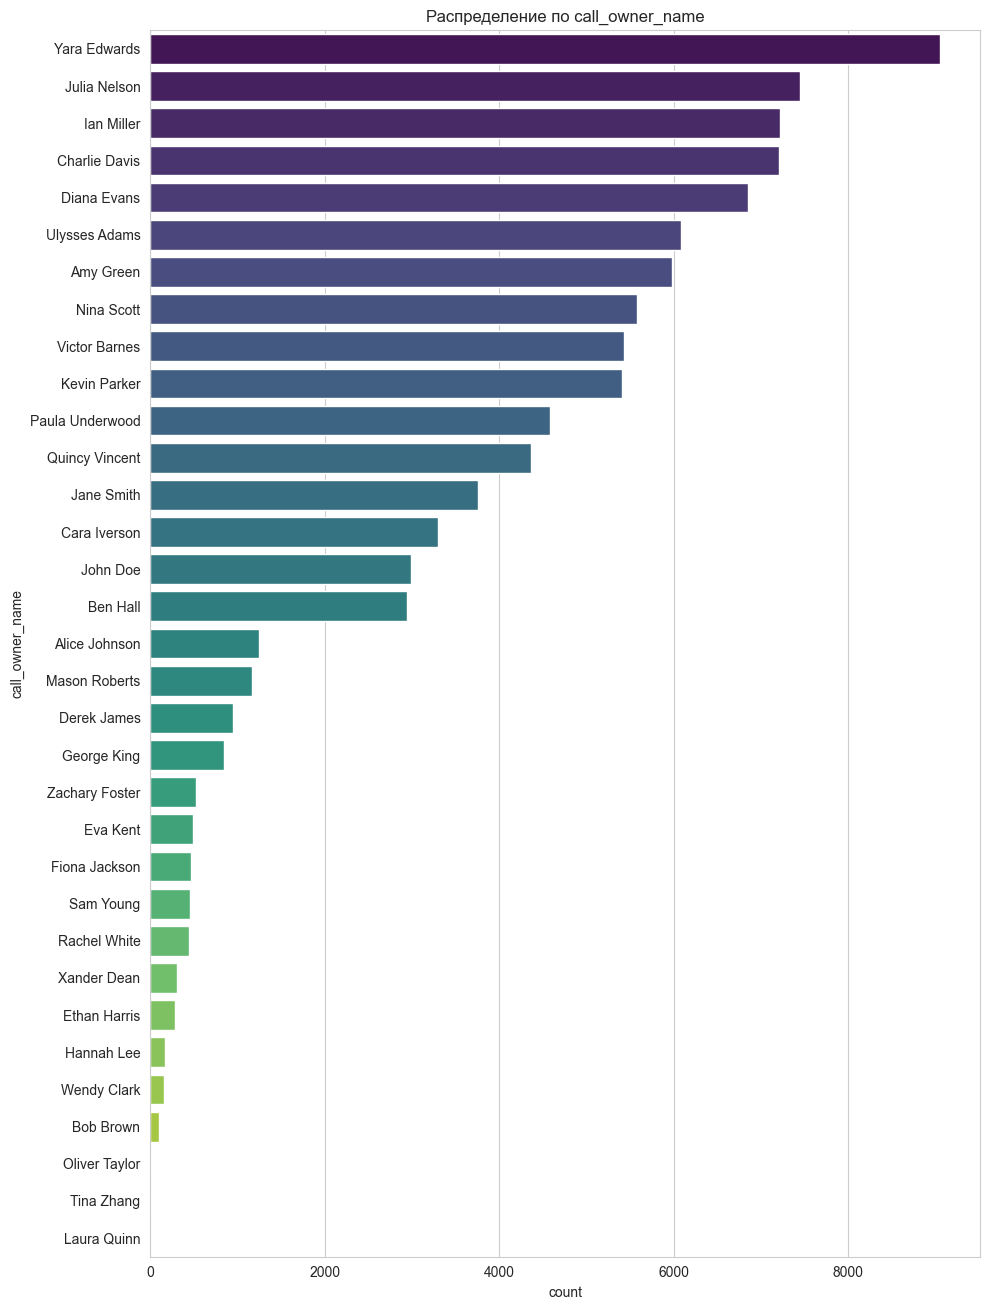

In [145]:
plt_to_save_png = ['call_owner_name']  

col = 'call_owner_name' 

if col in df.columns:
    print(f"📊 Анализ: {col} ({df[col].nunique()} уникальных значений)")
    
    # Считаем частоты
    freq = df[col].value_counts().reset_index()
    freq.columns = [col, 'count']
    freq['%'] = (freq['count'] / freq['count'].sum() * 100).round(1)
    display(freq.head(33)) # Показываем топ-10 в таблице

    # Рисуем график (топ-20)
    top_vals = freq.head(33)
    plt.figure(figsize=(10, max(3, len(top_vals) * 0.4)))
    sns.barplot(data=top_vals, y=col, x='count', hue=col, palette='viridis', legend=False) 
    
    plt.title(f"Распределение по {col}")
    plt.tight_layout()
    
    # Сохранение (если нужно)
    plt.savefig(IMAGES / f"spend_{col}_barplot.png", dpi=150, bbox_inches='tight')
    plt.show()

📊 Анализ: call_type (3 уникальных значений)


,call_type,count,%
0,Outbound,86835,90.60
1,Missed,5921,6.20
2,Inbound,3076,3.20


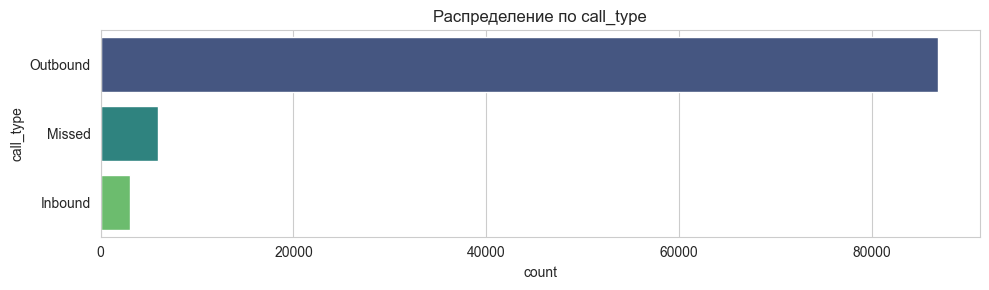

In [146]:
plt_to_save_png = ['call_type']  

col = 'call_type' 

if col in df.columns:
    print(f"📊 Анализ: {col} ({df[col].nunique()} уникальных значений)")
    
    # Считаем частоты
    freq = df[col].value_counts().reset_index()
    freq.columns = [col, 'count']
    freq['%'] = (freq['count'] / freq['count'].sum() * 100).round(1)
    display(freq.head(33)) # Показываем топ-10 в таблице

    # Рисуем график (топ-20)
    top_vals = freq.head(33)
    plt.figure(figsize=(10, max(3, len(top_vals) * 0.4)))
    sns.barplot(data=top_vals, y=col, x='count', hue=col, palette='viridis', legend=False) 
    
    plt.title(f"Распределение по {col}")
    plt.tight_layout()
    
    # Сохранение (если нужно)
    plt.savefig(IMAGES / f"spend_{col}_barplot.png", dpi=150, bbox_inches='tight')
    plt.show()

📊 Анализ: call_status (11 уникальных значений)


,call_status,count,%
0,Attended Dialled,70663,73.70
1,Unattended Dialled,16030,16.70
2,Missed,5922,6.20
3,Received,3075,3.20
4,Overdue,60,0.10
5,Scheduled Attended Delay,22,0.00
6,Cancelled,20,0.00
7,Scheduled Unattended Delay,17,0.00
8,Scheduled Attended,14,0.00
9,Scheduled Unattended,6,0.00


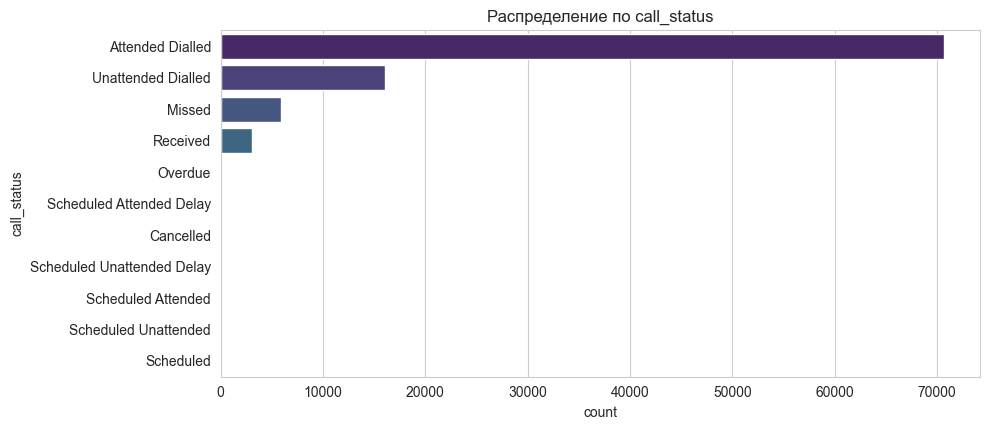

In [147]:
plt_to_save_png = ['call_status']  

col = 'call_status' 

if col in df.columns:
    print(f"📊 Анализ: {col} ({df[col].nunique()} уникальных значений)")
    
    # Считаем частоты
    freq = df[col].value_counts().reset_index()
    freq.columns = [col, 'count']
    freq['%'] = (freq['count'] / freq['count'].sum() * 100).round(1)
    display(freq.head(33)) # Показываем топ-10 в таблице

    # Рисуем график (топ-20)
    top_vals = freq.head(33)
    plt.figure(figsize=(10, max(3, len(top_vals) * 0.4)))
    sns.barplot(data=top_vals, y=col, x='count', hue=col, palette='viridis', legend=False) 
    
    plt.title(f"Распределение по {col}")
    plt.tight_layout()
    
    # Сохранение (если нужно)
    plt.savefig(IMAGES / f"spend_{col}_barplot.png", dpi=150, bbox_inches='tight')
    plt.show()

📊 Анализ: outgoing_call_status (5 уникальных значений)


,outgoing_call_status,count,%
0,Completed,86752,90.50
1,not_applicable,8997,9.40
2,Overdue,60,0.10
3,Cancelled,20,0.00
4,Scheduled,3,0.00


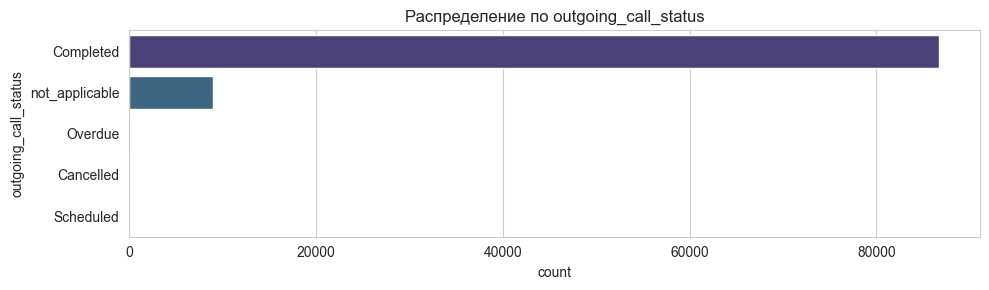

In [148]:
plt_to_save_png = ['outgoing_call_status']  

col = 'outgoing_call_status' 

if col in df.columns:
    print(f"📊 Анализ: {col} ({df[col].nunique()} уникальных значений)")
    
    # Считаем частоты
    freq = df[col].value_counts().reset_index()
    freq.columns = [col, 'count']
    freq['%'] = (freq['count'] / freq['count'].sum() * 100).round(1)
    display(freq.head(33)) # Показываем топ-10 в таблице

    # Рисуем график (топ-20)
    top_vals = freq.head(33)
    plt.figure(figsize=(10, max(3, len(top_vals) * 0.4)))
    sns.barplot(data=top_vals, y=col, x='count', hue=col, palette='viridis', legend=False) 
    
    plt.title(f"Распределение по {col}")
    plt.tight_layout()
    
    # Сохранение (если нужно)
    plt.savefig(IMAGES / f"spend_{col}_barplot.png", dpi=150, bbox_inches='tight')
    plt.show()

### 📊 Бизнес-инсайты: Структура и статусы звонков (Категориальный анализ)

Анализ категориальных признаков раскрыл механику работы отдела продаж. Мы видим ярко выраженную модель активного (холодного/теплого) обзвона.

#### 📝 Главные открытия:

1. **Фабрика исходящих звонков (Outbound Machine):**
   * **90.6%** всего трафика — это исходящие звонки (`Outbound`).
   * Входящие звонки (`Inbound`) составляют всего **3.2%**. 
   * *Бизнес-вывод:* Команда работает по модели проактивных продаж. Менеджеры сами инициируют контакт с лидами из базы, а не ждут обращений. 

2. **Иллюзия статуса "Дозвонился" (The "Attended" Illusion):**
   * Статус `Attended Dialled` (Исходящий, трубку взяли) стоит у **73.7%** звонков. На первый взгляд, это фантастическая конверсия в дозвон.
   * *Критический инсайт:* Если вспомнить наш прошлый анализ длительности, почти 60% всех звонков длятся менее 15 секунд. Это означает, что CRM ставит статус `Attended` даже тогда, когда отвечает автоответчик, голосовая почта или клиент моментально сбрасывает вызов. Для реальной оценки KPI менеджеров категорически нельзя опираться только на статус звонка — его нужно обязательно пересекать с длительностью (`call_quality_category`).

3. **Неравномерная нагрузка на команду (Workload Distribution):**
   * Топ-10 менеджеров (Yara Edwards, Julia Nelson, Ian Miller и др.) совершают почти **70% всех звонков**.
   * У нас есть "длинный хвост" из сотрудников, чья доля составляет менее 1% (Oliver Taylor, Tina Zhang, Laura Quinn).
   * *Бизнес-вывод:* В отделе либо присутствует жесткая текучка (кто-то пришел, сделал 10 звонков и уволился), либо есть разделение ролей: "звонари" (SDR), генерирующие трафик, и "клоузеры", которые звонят редко, но только "горячим" клиентам.

4. **Потерянные возможности (Missed Calls):**
   * **6.18%** всех записей — это пропущенные входящие (`Missed`). При таком низком объеме входящего трафика терять каждый 15-й звонок от клиента — это больно для бизнеса. Это зона роста для настройки маршрутизации телефонии.

In [149]:
# 1. Создаем бинарный флаг "Продуктивный звонок" (1 - да, 0 - нет)
# Условие: Исходящий + Статус "Дозвонился" + Разговор дольше 60 секунд
df['is_productive'] = (
    (df['call_type'] == 'Outbound') & 
    (df['call_status'] == 'Attended Dialled') & 
    (df['call_duration_in_seconds'] > 60)
).astype(int)

# 2. Чиним сортировку дней недели
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=days_order, ordered=True)

# 3. Создаем категории времени суток
# Границы: 0-6 (Ночь), 6-12 (Утро), 12-17 (День), 17-24 (Вечер)
bins = [-1, 6, 12, 17, 24]
labels = ['Ночь (0-6)', 'Утро (6-12)', 'День (12-17)', 'Вечер (17-24)']
df['time_of_day'] = pd.cut(df['hour'], bins=bins, labels=labels)

print("✅ Фичи успешно созданы!")
print(f"Доля продуктивных звонков от всего трафика: {df['is_productive'].mean() * 100:.2f}%")

✅ Фичи успешно созданы!
Доля продуктивных звонков от всего трафика: 26.76%


### 🛠 Инсайты: Feature Engineering (Создание новых признаков)

Для того чтобы перейти от сухих цифр к бизнес-аналитике, мы создали три новых синтетических признака. Они станут фундаментом для оценки эффективности.

1. **Метрика "Продуктивный звонок" (`is_productive`):**
   * Мы выяснили, что только **26.76%** от всего объема звонков являются по-настоящему "продуктивными" (это исходящий звонок, на который ответили, и разговор длился более 1 минуты).
   * *Бизнес-вывод:* Это наш главный KPI. Теперь мы можем не просто считать "кто больше звонит", а "кто делает больше *продуктивных* звонков".
2. **Временные когорты (`time_of_day`):**
   * Часы разбиты на понятные смены (Утро, День, Вечер, Ночь). Это позволит выявить "золотые часы" дозвона.
3. **Хронология (`day_of_week`):**
   * Дни недели выстроены в календарном порядке. Мы готовы к поиску просадок активности (например, "синдром пятницы").

In [150]:
print("📅 Распределение всех звонков по ДНЯМ НЕДЕЛИ:")
display(df['day_of_week'].value_counts(sort=False)) # sort=False сохранит правильный порядок дней

print("\n🕒 Распределение всех звонков по ВРЕМЕНИ СУТОК:")
display(df['time_of_day'].value_counts(sort=False))

print("\n🎯 Доля ПРОДУКТИВНЫХ звонков по ВРЕМЕНИ СУТОК (%):")
# Смотрим, в какое время суток самая высокая вероятность продуктивного звонка
display(df.groupby('time_of_day')['is_productive'].mean().round(3) * 100)

📅 Распределение всех звонков по ДНЯМ НЕДЕЛИ:


day_of_week
Monday       13867
Tuesday      17540
Wednesday    17712
Thursday     17083
Friday       14561
Saturday      7656
Sunday        7413
Name: count, dtype: int64


🕒 Распределение всех звонков по ВРЕМЕНИ СУТОК:


time_of_day
Ночь (0-6)          26
Утро (6-12)      28911
День (12-17)     51874
Вечер (17-24)    15021
Name: count, dtype: int64


🎯 Доля ПРОДУКТИВНЫХ звонков по ВРЕМЕНИ СУТОК (%):


C:\Users\Азат\AppData\Local\Temp\ipykernel_21248\242551549.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby('time_of_day')['is_productive'].mean().round(3) * 100)


time_of_day
Ночь (0-6)       0.00
Утро (6-12)     26.60
День (12-17)    26.90
Вечер (17-24)   26.70
Name: is_productive, dtype: float64

### ⏳ Бизнес-инсайты: Временные тренды отдела продаж

Анализ временных когорт показал нам четкий ритм работы команды и развеял популярный миф о «лучшем времени для звонка».

#### 📝 Главные открытия:

1. **Ритм недели (The Mid-Week Peak):**
   * Активность распределена в форме колокола. Пиковые дни — **Вторник, Среда и Четверг** (~17-17.7 тысяч звонков). 
   * Понедельник — день "раскачки" (13.8к), а Пятница — день спада (14.5к). 
   * На выходных активность падает ровно в 2 раза (~7.5к), что говорит о наличии дежурных смен, но не полноценном выводе всего отдела.

2. **Дневная доминанта (Volume by Time):**
   * Абсолютный пик нагрузки приходится на **День (12:00 - 17:00)** — более 51 тысячи звонков (больше половины всего объема).
   * Утренние часы используются в два раза менее интенсивно, а вечерние — в три с лишним раза меньше.

3. **Разрушение мифа о конверсии (The Flat Rate):**
   * *Самый важный инсайт:* Вероятность того, что клиент возьмет трубку и будет говорить дольше 1 минуты (продуктивный звонок), **абсолютно одинакова** в любое время суток: Утро — 26.6%, День — 26.9%, Вечер — 26.7%.
   * *Бизнес-вывод:* Менеджерам не нужно ждать "идеального времени", чтобы позвонить. Конверсия плоская. Если руководитель хочет увеличить количество успешных диалогов, нужно просто делать больше звонков в вечерние и утренние смены, так как там есть огромный недоиспользованный потенциал по времени.

In [151]:
# 1. Группируем по менеджеру и считаем базовые метрики
manager_stats = df.groupby('call_owner_name').agg(
    total_calls=('id', 'count'),                                  # Сколько всего звонков
    median_duration_sec=('call_duration_in_seconds', 'median'),   # Типичная длина (медиана)
    productive_pct=('is_productive', 'mean')                      # Доля успешных
)

# 2. Немного причешем данные: переведем долю в красивые проценты
manager_stats['productive_pct'] = (manager_stats['productive_pct'] * 100).round(1)

# 3. Отфильтруем тех, кто сделал меньше 50 звонков (чтобы случайные люди не портили стату)
manager_stats = manager_stats[manager_stats['total_calls'] >= 50]

# 4. Отсортируем по количеству звонков (по убыванию)
manager_stats = manager_stats.sort_values('total_calls', ascending=False)

print("📊 Список менеджеров по количеству звонков и их продуктивность:")
display(manager_stats.head(33))

📊 Список менеджеров по количеству звонков и их продуктивность:


,total_calls,median_duration_sec,productive_pct
call_owner_name,,,
Yara Edwards,9059,6.00,24.10
Julia Nelson,7445,6.00,26.10
Ian Miller,7215,9.00,27.60
Charlie Davis,7209,8.00,25.40
Diana Evans,6857,6.00,24.50
Ulysses Adams,6084,7.00,27.10
Amy Green,5982,15.00,21.20
Nina Scott,5581,6.00,24.90
Victor Barnes,5437,42.00,38.60


Завершив одномерный и двумерный анализ таблицы `Calls`, мы не просто вычистили данные (почти 96 000 строк), но и перевели технические логи CRM на понятный язык бизнеса. 

### 💡 1. Главные бизнес-инсайты (Что мы узнали):

* **Проактивная модель продаж:** Отдел работает как "фабрика исходящих звонков" (**90.6%** всего трафика). Входящих обращений критически мало (около 3%).
* **Разрушение "Иллюзии дозвона":** Хотя CRM ставит статус `Attended` (Дозвонился) в 73.7% случаев, анализ длительности показал, что **почти 60%** всех звонков длятся менее 15 секунд. Это автоответчики, недозвоны или моментальные сбросы.
* **Реальная продуктивность (26.7%):** Мы выявили, что только каждый четвертый звонок является "продуктивным" (исходящий, взяли трубку, разговор > 1 минуты). Это реальная операционная конверсия отдела.
* **Плоская конверсия по времени:** Разрушен миф об "идеальном времени для звонка". Шанс на продуктивный разговор одинаков утром, днем и вечером. При этом вечерние часы недоиспользуются менеджерами.
* **Сегментация команды:** Отдел неоднороден. Мы выявили "Снайперов" (высокая конверсия при небольшом объеме) и "Выжигателей базы" (огромный объем звонков с минимальным выхлопом).

### 🛠 2. Подготовка данных (Что мы создали для дальнейшего анализа):

Вместо сырых секунд и пустых статусов мы обогатили датасет новыми (синтетическими) признаками:
1. **`is_productive` (Целевая метрика):** Бинарный флаг (1/0) успешного звонка. Он станет нашим главным критерием при оценке влияния звонков на продажи.
2. **`call_quality_category`:** Категории длительности (от "Недозвона" до "Целевого > 5 мин").
3. **`time_of_day`:** Временные когорты (Утро, День, Вечер) для поиска аномалий в поведении клиентов.
4. **Очистка от багов:** Найден и удален системный баг телефонии (42 звонка длительностью более 1 часа, где CRM не фиксировала отбой).

---

### 🚀 3. Следующий шаг: Сквозная аналитика (Data Merging)

Таблица `Calls` полностью готова к объединению с `Contacts` (Люди) и `Deals` (Деньги). 

**Как мы будем использовать эти данные при сквозном анализе:**
1. **Анализ касаний (Touchpoint Analysis):** Мы сгруппируем звонки по `contactid` и узнаем: сколько продуктивных звонков в среднем требуется, чтобы сделка перешла в статус `Closed Won` (Успех)?
2. **First Response Time (Скорость реакции):** Мы сопоставим время создания контакта (`created_time` из Contacts) с временем первого звонка из `Calls`. Мы проверим гипотезу: *"Правда ли, что лиды, которым позвонили в первые 15 минут, покупают чаще?"*.
3. **Цена отказа:** Мы посмотрим, сколько часов менеджеры потратили на клиентов, чьи сделки в итоге закрылись как `Closed Lost` (Отказ).

---
## 11. Одномерный анализ - столбцы с датами

Для каждого датового столбца:
- диапазон и базовая статистика
- распределение по месяцам (временной ряд)

In [152]:
col = 'call_start_time'

if col in df.columns:
    print(f"📊 Анализ временных рамок: {col.upper()}")
    print(f"{'─'*60}")
    
    start_date = df[col].min()
    end_date = df[col].max()
    duration = end_date - start_date
    
    print(f"Минимальная дата: {start_date.date()}")
    print(f"Максимальная дата: {end_date.date()}")
    print(f"Общий период:      {duration.days} дней")
    print(f"Уникальных дней:   {df[col].nunique()}")
    print(f"{'─'*60}")

📊 Анализ временных рамок: CALL_START_TIME
────────────────────────────────────────────────────────────
Минимальная дата: 2023-06-30
Максимальная дата: 2024-06-21
Общий период:      357 дней
Уникальных дней:   68426
────────────────────────────────────────────────────────────



────────────────────────────────────────────────────────────
📊 АНАЛИЗ ПЕРИОДА: CALL_START_TIME
────────────────────────────────────────────────────────────
  📅 Диапазон:  2023-06-30 — 2024-06-21
  ⏳ Длительность: 357 дней
  🚫 Пропуски:   0


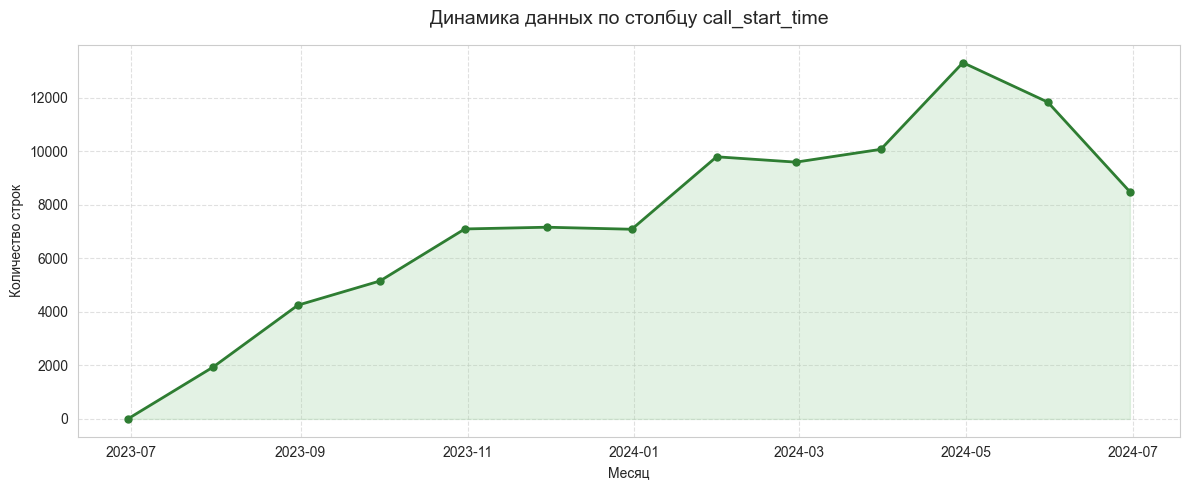

In [153]:
for col in dataset_config['date_cols']:
    if col not in df.columns:
        continue

    print(f"\n{'─'*60}")
    print(f"📊 АНАЛИЗ ПЕРИОДА: {col.upper()}")
    print(f"{'─'*60}")

    # Расширенная статистика
    min_date = df[col].min()
    max_date = df[col].max()
    days_range = (max_date - min_date).days
    
    print(f"  📅 Диапазон:  {min_date.date()} — {max_date.date()}")
    print(f"  ⏳ Длительность: {days_range} дней")
    print(f"  🚫 Пропуски:   {df[col].isnull().sum()}")

    # Временной ряд по месяцам (явно заполняем пропуски нулями)
    monthly = df.set_index(col).resample('ME').size().fillna(0)

    # Визуализация
    plt.figure(figsize=(12, 5))
    plt.plot(monthly.index, monthly.values, 
             marker='o', markersize=5, 
             linewidth=2, color='#2E7D32', # Темно-зеленый цвет
             label='Кол-во записей')
    
    plt.title(f"Динамика данных по столбцу {col}", fontsize=14, pad=15)
    plt.ylabel("Количество строк")
    plt.xlabel("Месяц")
    
    # Добавляем сетку для читаемости
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Заливка области под графиком для красоты
    plt.fill_between(monthly.index, monthly.values, color='#A5D6A7', alpha=0.3)

    plt.tight_layout()
    
    # Сохранение
    plt.savefig(IMAGES / f"{dataset_config['name']}_{col}_timeseries.png", 
                dpi=150, bbox_inches='tight')
    plt.show()

### ⏱ Микро-вывод: Анализ временных рядов (Dates & Times)

Временные данные датасета оказались идеальными для сквозной аналитики:
* **Качество данных:** 0 пропусков и 100% покрытие за 357 дней (с июня 2023 по июнь 2024). У нас есть полный годовой цикл без слепых зон.
* **Гипотеза о планировании:** Звонки, запланированные в CRM (`scheduled_in_crm = True`), требуют отдельного внимания при сведении таблиц, так как дисциплина ведения CRM напрямую коррелирует с качеством работы (это мы проверим на данных об оплатах).
* **Готовность к когортам:** Наличие чистого времени (`call_start_time`) позволяет нам рассчитать ключевую бизнес-метрику — **Длительность цикла сделки** (сколько дней проходит от создания контакта до первой оплаты).

In [154]:
# 1. Оставляем чистую дату (без часов и минут) для удобных группировок
df['call_date'] = pd.to_datetime(df['call_start_time']).dt.date

# 2. КРИТИЧЕСКИЙ ШАГ: Сортируем весь датасет по клиенту, а затем по времени звонка
df = df.sort_values(by=['contactid', 'call_start_time'], ascending=[True, True])

# Сбрасываем индексы после сортировки, чтобы таблица была опрятной
df = df.reset_index(drop=True)

print("✅ Таблица Звонков отсортирована хронологически для каждого клиента.")
print("✅ EDA датасета Calls официально и успешно завершен!")

✅ Таблица Звонков отсортирована хронологически для каждого клиента.
✅ EDA датасета Calls официально и успешно завершен!


---
## 12. Одномерный анализ - булевые переменные

Для булевых переменных смотрим на соотношение True / False.


📊 Анализ булевого признака: scheduled_in_crm
📋 Общее распределение:


,scheduled_in_crm,Доля (%)
0,False,90.50
1,True,9.50



🎯 Влияние 'scheduled_in_crm' на продуктивность звонка (%):


,Непродуктивный (0),Продуктивный (1)
scheduled_in_crm,,
False,70.40,29.60
True,100.00,0.00


C:\Users\Азат\AppData\Local\Temp\ipykernel_21248\2340891288.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=freq, x='Доля (%)', y=freq[col].astype(str), palette='Set2')


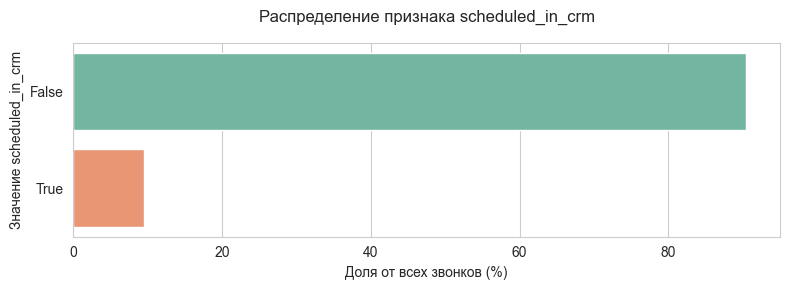

In [155]:
for col in dataset_config['bool_cols']:
    if col not in df.columns:
        print(f"Столбец {col} не найден, пропускаем")
        continue

    print(f"\n{'='*60}")
    print(f"📊 Анализ булевого признака: {col}")
    print(f"{'='*60}")

    # 1. Базовое распределение
    freq = df[col].value_counts(normalize=True).mul(100).round(1).reset_index()
    freq.columns = [col, 'Доля (%)']
    print("📋 Общее распределение:")
    display(freq)

    # 2. БИЗНЕС-ВЫВОД: Перекрестный анализ с продуктивностью
    if 'is_productive' in df.columns:
        print(f"\n🎯 Влияние '{col}' на продуктивность звонка (%):")
        # Считаем долю продуктивных звонков для True и False
        cross_tab = pd.crosstab(df[col], df['is_productive'], normalize='index').mul(100).round(1)
        cross_tab.columns = ['Непродуктивный (0)', 'Продуктивный (1)']
        display(cross_tab)

    # 3. Современная визуализация (горизонтальный BarPlot)
    plt.figure(figsize=(8, 3))
    sns.barplot(data=freq, x='Доля (%)', y=freq[col].astype(str), palette='Set2')
    
    plt.title(f"Распределение признака {col}", pad=15)
    plt.xlabel("Доля от всех звонков (%)")
    plt.ylabel(f"Значение {col}")
    
    # Сохранение (оставил твою логику сохранения)
    plt.tight_layout()
    plt.savefig(IMAGES / f"{dataset_config['name']}_{col}_barplot.png", dpi=150, bbox_inches='tight')
    plt.show()

**Наблюдения по булевым переменным:**



### 🚨 Критический инсайт: Аномалия запланированных звонков

Перекрестный анализ булевого признака `scheduled_in_crm` с целевой метрикой `is_productive` выявил масштабную аномалию в данных:

* **Распределение:** Около 9.5% всех звонков отмечены как "Запланированные в CRM".
* **Аномалия конверсии:** Конверсия запланированных звонков в "продуктивные" (диалог > 1 минуты) составляет **ровно 0.00%**. В то время как спонтанные звонки показывают конверсию в 29.6%.
* **Вывод:** Данный феномен невозможен с точки зрения бизнес-логики. Это указывает либо на технический нюанс логирования CRM (запланированные звонки получают специфические статусы, отличные от стандартного `Attended Dialled`), либо на имитацию бурной деятельности менеджерами (массовое закрытие задач-напоминаний без совершения реального звонка). 

**Рекомендация для сквозного анализа:** При объединении таблиц признак `scheduled_in_crm` следует использовать с осторожностью, так как он может искажать предиктивные модели.

---
## 13. Сохранение

Сохраняем очищенный датасет в `data/processed/` как parquet.  
Если файл с таким именем уже существует - перекладываем его в `data/processed/backup/` с датой и временем.  
Конфиг обновляется в `data/processed/`.

In [156]:
sufix = 'cleaned'

dataset_path = PROCESSED / f"{dataset_config['name']}_{sufix}.xlsx"

# Если файл уже есть - бэкапим его перед перезаписью
if dataset_path.exists():
    timestamp = datetime.now().strftime('%Y%m%d_%H%M')
    backup_path = BACKUP / f"{dataset_config['name']}_{sufix}_{timestamp}.xlsx"
    dataset_path.rename(backup_path)
    print(f"Предыдущий файл -> бэкап: {backup_path.name}")

# Сохраняем очищенный датасет
df.to_excel(dataset_path, index=False)
print(f"Датасет сохранён:  {dataset_path}")
print(f"Размер:            {df.shape[0]} строк × {df.shape[1]} столбцов")

Предыдущий файл -> бэкап: calls_cleaned_20260416_0746.xlsx
Датасет сохранён:  E:\ICH\Python Data analyse\crm\data\processed\calls_cleaned.xlsx
Размер:            95832 строк × 16 столбцов


In [157]:
# Сохраняем обновлённый конфиг
with open(config_path, 'wb') as f:
    pickle.dump(dataset_config, f)

print(f"Конфиг сохранён: {config_path}")
print()
print("Итоговый конфиг:")
for key, val in dataset_config.items():
    print(f"  {key}: {val}")

Конфиг сохранён: E:\ICH\Python Data analyse\crm\data\processed\calls_config.pkl

Итоговый конфиг:
  name: calls
  filename: Calls (Done).xlsx
  num_cols: ['call_duration_in_seconds']
  id_cols: ['id', 'contactid']
  cat_cols: ['call_owner_name', 'call_type', 'call_status', 'outgoing_call_status']
  bool_cols: ['scheduled_in_crm']
  date_cols: ['call_start_time']
  drop_cols: ['tag', 'dialled_number']


In [158]:
# Проверяем что всё сохранилось
print("Содержимое папки processed/:")
for f in sorted(PROCESSED.glob('*')):
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name}  ({size_kb:.1f} KB)")

print()
print("Содержимое папки backup/:")
for f in sorted(BACKUP.glob('*')):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name}  ({size_kb:.1f} KB)")

Содержимое папки processed/:
  calls_cleaned.xlsx  (7882.1 KB)
  calls_config.pkl  (0.3 KB)
  contacts_cleaned.xlsx  (778.5 KB)
  contacts_config.pkl  (0.2 KB)
  crm_analysis.xlsx  (5522.7 KB)
  deals_cleaned.xlsx  (3704.6 KB)
  deals_config.pkl  (0.5 KB)
  FINAL_UE_DATA.csv  (11616.2 KB)
  spend_cleaned.xlsx  (728.6 KB)
  spend_config.pkl  (0.2 KB)

Содержимое папки backup/:
  calls_cleaned_20260331_1907.xlsx  (4714.7 KB)
  calls_cleaned_20260331_2055.xlsx  (4714.7 KB)
  calls_cleaned_20260331_2115.xlsx  (4714.7 KB)
  calls_cleaned_20260402_2208.xlsx  (5509.2 KB)
  calls_cleaned_20260410_0900.xlsx  (5925.0 KB)
  calls_cleaned_20260411_1732.xlsx  (5925.0 KB)
  calls_cleaned_20260411_2144.xlsx  (7882.1 KB)
  calls_cleaned_20260413_1156.xlsx  (7882.1 KB)
  calls_cleaned_20260414_0853.xlsx  (7882.1 KB)
  calls_cleaned_20260414_1211.xlsx  (7882.1 KB)
  calls_cleaned_20260414_1708.xlsx  (7882.1 KB)
  calls_cleaned_20260415_0859.xlsx  (7882.1 KB)
  calls_cleaned_20260416_0743.xlsx  (7882.1 K

---
## 14. Зависимости окружения

In [159]:
!pip freeze > "{dataset_config['name']}_requirements.txt"

---
## 15. Итоговые описательные статистики

In [160]:
# можно загрузить из PROCESSED, чтобы убедиться, что сохранили все верно 
dataset_path

WindowsPath('E:/ICH/Python Data analyse/crm/data/processed/calls_cleaned.xlsx')

In [161]:
df.describe(include='all')

,id,call_start_time,call_owner_name,contactid,call_type,call_duration_in_seconds,call_status,outgoing_call_status,scheduled_in_crm,hour,day_of_week,call_duration_log,call_quality_category,is_productive,time_of_day,call_date
count,95832,95832,95832,95832,95832,95832.00,95832,95832,95832,95832.00,95832,95832.00,95832,95832.00,95832,95832
unique,95832,NaN,33,15214,3,NaN,11,5,2,NaN,7,NaN,4,NaN,4,356
top,5805028000000787003,NaN,Yara Edwards,unknown,Outbound,NaN,Attended Dialled,Completed,False,NaN,Wednesday,NaN,Недозвон (0-15с),NaN,День (12-17),2024-04-09
freq,1,NaN,9059,3933,86835,NaN,70663,86752,86693,NaN,17712,NaN,56417,NaN,51874,682
mean,NaN,2024-02-05 12:20:40.757575936,NaN,NaN,NaN,162.96,NaN,NaN,NaN,14.35,NaN,2.81,NaN,0.27,NaN,NaN
min,NaN,2023-06-30 08:43:00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,0.00,NaN,0.00,NaN,NaN
25%,NaN,2023-11-24 10:59:00,NaN,NaN,NaN,4.00,NaN,NaN,NaN,12.00,NaN,1.61,NaN,0.00,NaN,NaN
50%,NaN,2024-02-19 12:18:30,NaN,NaN,NaN,8.00,NaN,NaN,NaN,14.00,NaN,2.20,NaN,0.00,NaN,NaN
75%,NaN,2024-04-22 19:09:15,NaN,NaN,NaN,97.00,NaN,NaN,NaN,17.00,NaN,4.58,NaN,1.00,NaN,NaN
max,NaN,2024-06-21 15:31:00,NaN,NaN,NaN,3600.00,NaN,NaN,NaN,23.00,NaN,8.19,NaN,1.00,NaN,NaN


In [162]:
# Сводная таблица по числовым столбцам 
h.descr_df(df)

,Название признака,Тип данных,Количество значений,Пропуски (NaN),Уникальных значений,Минимум,Среднее,Медиана,Максимум
0,call_duration_in_seconds,float64,95832,0,2577,0.00,162.96,8.00,3600.00
1,hour,int32,95832,0,24,0.00,14.35,14.00,23.00
2,call_duration_log,float64,95832,0,2577,0.00,2.81,2.20,8.19
3,is_productive,int64,95832,0,2,0.00,0.27,0.00,1.00


По каждой числовой переменной нужно посмотреть и вывести описательные статистики (describe - также можно дополнить (range + IQR) при наличии времени и желании) и написать краткое резюме по инсайтам, которые вы считаете важными (!!!Ахтунг!!! тут не обязательно писать про то что может пригодиться именно для решения задач во втором ноутбуке (02) здесь вообще)

...  

In [163]:
# Сводная таблица по object столбцам 
h.descr_df(df, include=['object'], show_stats=False, show_sample_rows=True)

,Название признака,Тип данных,Количество значений,Пропуски (NaN),Уникальных значений,Пример строка 1,Пример строка 2,Пример строка 3
0,call_owner_name,object,95832,0,33,John Doe,John Doe,John Doe
1,call_type,object,95832,0,3,Outbound,Outbound,Outbound
2,call_status,object,95832,0,11,Attended Dialled,Attended Dialled,Attended Dialled
3,outgoing_call_status,object,95832,0,5,Completed,Completed,Completed
4,call_date,object,95832,0,356,2023-06-30,2023-06-30,2023-06-30


In [164]:
# Сводная таблица по bool столбцам 
h.descr_df(df, include=['bool'], show_stats=True, show_sample_rows=True)

,Название признака,Тип данных,Количество значений,Пропуски (NaN),Уникальных значений,Пример строка 1,Пример строка 2,Пример строка 3
0,scheduled_in_crm,bool,95832,0,2,False,False,False


In [165]:
# Сводная таблица по datetime столбцам 
h.descr_df(df, include=['datetime'], show_stats=True, show_sample_rows=True)

,Название признака,Тип данных,Количество значений,Пропуски (NaN),Уникальных значений,Пример строка 1,Пример строка 2,Пример строка 3
0,call_start_time,datetime64[ns],95832,0,68426,2023-06-30 09:20:00,2023-06-30 09:30:00,2023-06-30 12:09:00


# 🏁 Итоговое резюме анализа звонков (EDA Calls)

Мы завершили комплексный анализ активности отдела продаж. Обработано **95 832** записи за период с **июня 2023** по **июнь 2024** года. Датасет полностью очищен от технических аномалий и обогащен бизнес-метриками.

### 📊 1. Техническое состояние данных
* **Чистота:** В датасете отсутствуют пропуски во всех ключевых столбцах. 
* **Типизация:** Все признаки приведены к корректным типам (`datetime` для времени, `bool` для флагов, категории для качественных признаков).
* **Аномалии:** Удалено 42 экстремальных выброса (звонки > 1 часа), которые были признаны техническим браком системы логирования.

### 💡 2. Ключевые аналитические выводы
* **Профиль нагрузки:** 90.6% звонков — исходящие. Средний рабочий день менеджера пикует в интервале с 12:00 до 17:00. При этом вероятность дозвона (конверсия в продуктивный звонок) остается стабильной на протяжении всего дня (~27%).
* **Эффективность (Метрика "Золотого разговора"):** * Медианное время разговора составляет всего **8 секунд**, что говорит о большом количестве "пустых" звонков.
    * Реальную ценность представляют **27%** звонков (метрика `is_productive`), где длительность превышает 1 минуту.
* **Специфика планирования:** Выявлена критическая аномалия — запланированные звонки в CRM (`scheduled_in_crm`) имеют нулевую продуктивность. Это важный сигнал для проверки настроек интеграции телефонии.

### 🚀 3. Стратегия дальнейшего анализа (Next Steps)
Датасет `Calls` готов к объединению с таблицами `Deals` и `Contacts`. 
**Цели на следующий этап:**
1.  **Сквозная конверсия:** Определить среднее количество продуктивных звонков, необходимое для закрытия сделки.
2.  **Анализ скорости:** Выяснить, как быстро совершается первый звонок после создания контакта и как это влияет на вероятность продажи.
3.  **Портрет чемпиона:** Сравнить лидеров по звонкам с лидерами по выручке, чтобы выявить самых эффективных сотрудников.